# Figure3: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure3/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `Figure_3a_T_NK_marker_dotplot` — resource-data sheet for the corresponding panel.
- `Figure_3b_TCR_sharing_edges` — resource-data sheet for the corresponding panel.
- `Figure_3b_TCR_sharing_nodes` — resource-data sheet for the corresponding panel.
- `Figure_3c_selected_T_cell_cluster_proportions` — resource-data sheet for the corresponding panel.
- `Figure_3d_CXCL13_CD8_mIF_by_image_field` — resource-data sheet for the corresponding panel.
- `Figure_3d_CXCL13_CD8_mIF_patient_summary` — resource-data sheet for the corresponding panel.
- `Figure_3e_CXCR4_CXCL12_major_cell_dotplot` — resource-data sheet for the corresponding panel.
- `Figure_3e_CXCR4_T_cell_dotplot` — resource-data sheet for the corresponding panel.
- `Figure_3f_CXCL12_all_cells_expression` — resource-data sheet for the corresponding panel.
- `Figure_3f_CXCL12_fibroblast_expression` — resource-data sheet for the corresponding panel.
- `Figure_3g_CXCR4_cytotoxic_CD8_expression` — resource-data sheet for the corresponding panel.
- `Figure_3g_CXCR4_exhausted_CD8_expression` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [38]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


# Figure 3 plotting code\n\nOrganized copy of the manuscript plotting notebook. This standalone notebook runs from `code/`; inputs are in `../data/` and outputs are written to `../output/`. Large inputs are relative symbolic links, described in `../../data/DATA_INPUT_MANIFEST.tsv`.\n

# figure 3 vlz

- kernel: r_env, R 4.1.3
- date: 2023-12-28

## load

In [39]:
library(tidyverse)
library(tools)
if (requireNamespace("logging", quietly = TRUE)) { library(logging); logging::basicConfig() } else { loginfo <- function(...) invisible(NULL) }
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(Seurat)
if (requireNamespace("maftools", quietly = TRUE)) library(maftools)
library(ComplexHeatmap)

source('shared/r_funcs.r')

theme_set(theme_pubr())

options(warn = -1)

outdir <- "../output"
create_dir(outdir)

In [40]:
# f_pat_gp <- '../data/Figure3/tables/patient_info_v2.tsv'
f_pat_gp <- '../data/Figure3/local_data/patient_info.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)

## 3a: T cell markers

- 2024-01-02: update gene list

In [41]:
f_fig3a <- '../data/Figure3/core_inputs/Figure_3a_T_NK_marker_dotplot.tsv'

ctype_order <- c(
    'NK', 'NK_CX3CR1',
    'CD4_CXCL13', 'CD4_KLRB1', 'Treg_LTB', 'Treg_TNFRSF4',
    'CD8_CXCL13', 'CD8_TYMS', # exhau
    'CD8_CD74', 'CD8_IFIT1', # others
    'CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK', 'CD8_KLRB1', # cyto
    'T_MKI67', 'T_Mito', 'T_IL7R', 'T_Ribo'
)
markers <- list(
    'NK profile' = c('NCAM1', 'FCER1G', 'KLRC1', 'TYROBP'),  # NK
    'T profile' = c('CD3E', 'CD4', 'TNFRSF4', 'CD8A', 'CD8B'),  # major markers
    'Treg' = c('FOXP3', 'IKZF2'),
    'Naive/TCM' = c('CCR7', 'SELL', 'TCF7', 'IL7R'),
    'Exhaustion' = c('PDCD1', 'HAVCR2', 'ENTPD1', 'TNFRSF9', 'CXCL13'),  # exhaustion
    'Cytotocity' = c('CST7', 'GZMH', 'GZMK', 'GZMM', 'IFNG', 'PRF1', 'KLRG1', 'NKG7', 'GZMA'), # cyto
    'Resident' = c('CD101', 'CXCR6', 'CD69'),
    'Others' = c('CX3CR1', 'ITGAE', 'MT-ATP6', 'MT-ND3', 'ANXA1', 'CCL5', 'KLRB1', 'MKI67', 'RPL30')
)

In [42]:
dp_fig3a <- read_tsv(f_fig3a, show_col_types = FALSE) %>%
    filter(cell_group %in% ctype_order) %>%
    mutate(cell_group = factor(cell_group, levels = ctype_order),
           gene = factor(gene, levels = unlist(markers, use.names = FALSE)),
           color_value = as.numeric(scale(mean_expression)), .by = gene)

In [43]:
# Source Data already contains the final T/NK cell-group labels and marker summaries.

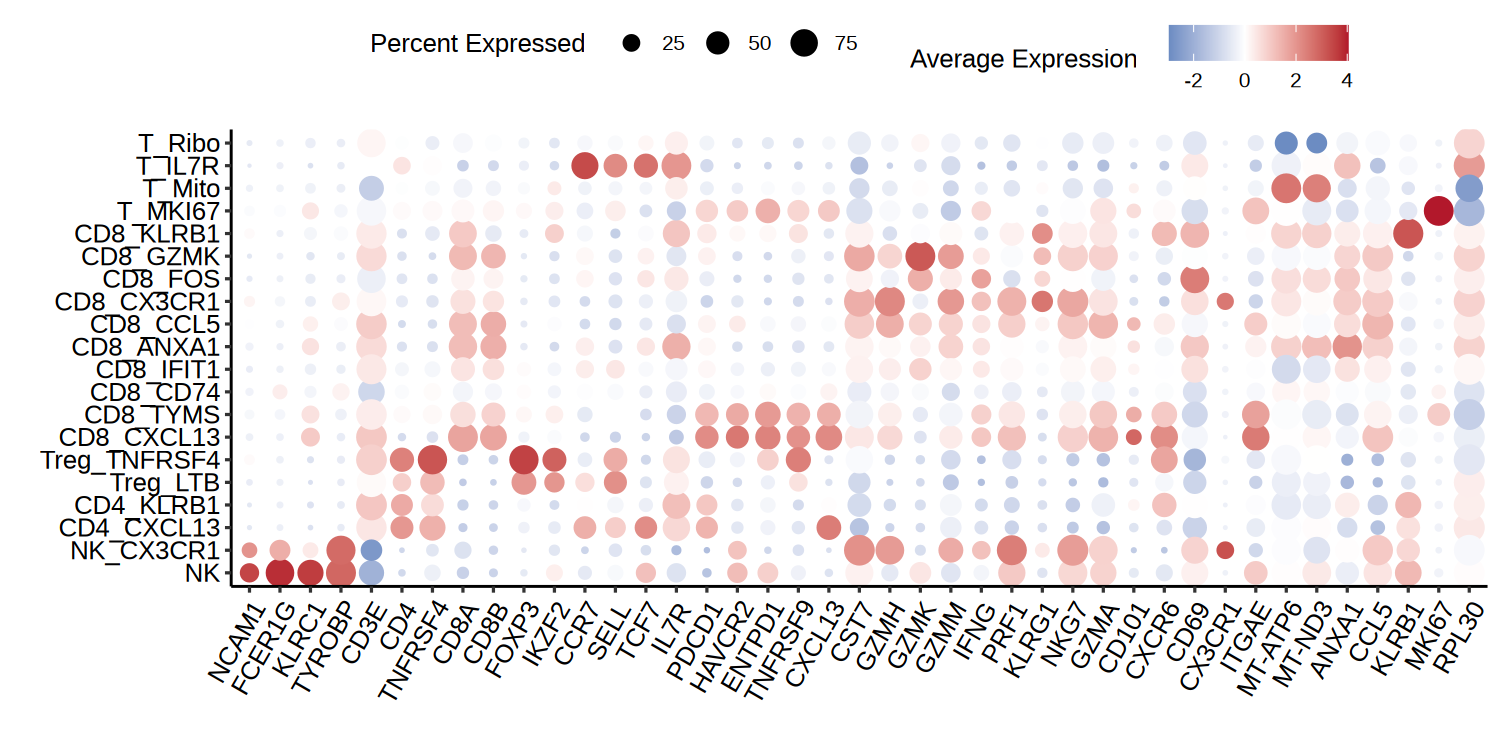

In [44]:
p <- ggplot(dp_fig3a, aes(x = gene, y = cell_group)) +
    geom_point(aes(size = percent_expressed, color = color_value)) +
    scale_size(range = c(0, 6), name = 'Percent Expressed') +
    scale_color_gradient2(low = '#2166AC', mid = 'white', high = '#B2182B', name = 'Average Expression') +
    labs(x = '', y = '') + theme(axis.text.x = element_text(angle = 60, hjust = 0.95, vjust = 0.95))
ggsave(filename = str_glue('{outdir}/fig3a-dot_t_marker.pdf'), plot = p, width = 14, height = 6)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 150)
p


## 3b: TCR sharing network

- date: 2024-01-02

In [45]:
f_node <- '../data/Figure3/stage4/a03_tcr/net_vlz_old/net_node_info.csv'
f_edge <- '../data/Figure3/stage4/a03_tcr/net_vlz_old/net_edge_info.csv'

# to rename cell types
celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)
# to rename cell states (use renamed cell type)
cell_state_map <- list(
    'others' = c('Treg_LTB')
)

df_edge <- read_csv(f_edge, show_col_types = F)
df_node <- read_csv(f_node, show_col_types = F)

In [46]:
# update cell types
for (nm in names(celltype_map)) {
    df_node$node[df_node$node %in% celltype_map[[nm]]] <- nm
    df_edge$from[df_edge$from %in% celltype_map[[nm]]] <- nm
    df_edge$to[df_edge$to %in% celltype_map[[nm]]] <- nm
}
df_edge$edge_type <- paste(df_edge$from, df_edge$to, sep = '->')
# node: update cell states
for (nm in names(cell_state_map)) {
    df_node$node_type[df_node$node %in% cell_state_map[[nm]]] <- nm
}

df_node %>% write_tsv(str_glue('{outdir}/fig3b-net_tcr_sharing-node_info.tsv'))
df_edge %>% write_tsv(str_glue('{outdir}/fig3b-net_tcr_sharing-edge_info.tsv'))

In [47]:
exhau_cyto_netplot <- function(df_node, df_edge, color_by, edge_weight='weight', text_size = 6, pt_size = 8) {
  # Transition Network plot show TCR sharing and cell type exhuastion/cytotocity score.
  # Args:
  #   df_node: data frame of network nodes, include columns: node, exhau, cyto, ...
  #   df_edge: data frame of network edges, include columns: start_exhau, start_cyto, end_exhau, end_cyto, edge_type, ...
  #   color_by: color network nodes by this column in df_node
  #   edge_weight: column in df_edge indicates edge wight (usually the TCR sharing score)
  # Returns:
  #   a ggplot object.
  require(ggrepel)
  p <- ggplot(df_node, aes(exhau, cyto))
  # add edge
  edges <- df_edge %>%
    pull(edge_type) %>%
    unique()
  for (e in edges) {
    tmp <- df_edge %>% 
      filter(edge_type == e) %>% 
      distinct()
    if (nrow(tmp) > 1) {
      stop(sprintf('edge: %s more one records', e))
    }
    p <- p + 
      geom_segment(data = tmp, 
                   aes(x = `start_exhau`, y = `start_cyto`, xend = `end_exhau`, yend = `end_cyto`), 
                   # size = tmp[[edge_weight]] * 40,
                   size = tmp[[edge_weight]] * 40,  # new version ggplot use linewidth (v3.4.0)
                   alpha = 0.8,
                   color = 'gray')
  }
  # add node
  p <- p + 
    geom_point(aes(color = .data[[color_by]]), size = pt_size, alpha = 0.8) +
    geom_text_repel(aes(label = node), show.legend = F, size = text_size) + 
    labs( x = 'Exhaustion Score', y = 'Cytotoxicity Score')
  return(p)
}

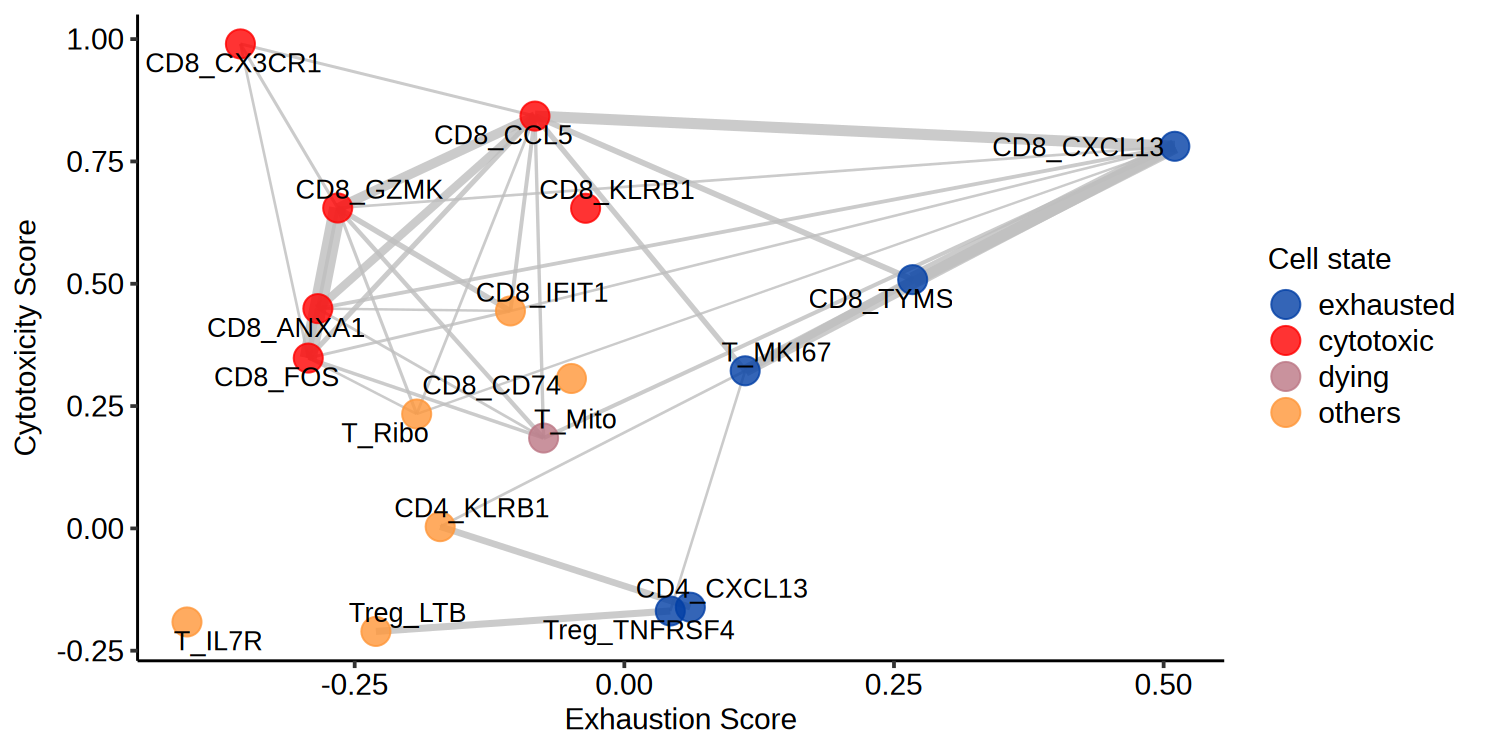

In [48]:
df_node$node_type <- factor(df_node$node_type, levels = c('exhausted', 'cytotoxic', 'dying', 'others'))
p <- exhau_cyto_netplot(df_node = df_node, df_edge = df_edge, color_by = 'node_type', text_size = 4.5, pt_size = 6) +
    scale_color_manual(values = c('exhausted' = '#023fa5', 
                                  'cytotoxic' = 'red', 
                                  'dying' = '#bb7784', 
                                  'others' = '#ff9639')) +
    labs(color = 'Cell state') +
    theme_pubr(base_size = 14) +
    theme(legend.position = 'right', legend.text = element_text(size = 14), legend.title = element_text(size = 14))
ggsave(filename = str_glue('{outdir}/fig3b-net_tcr_sharing-node_type.pdf'), plot = p, width = 9, height = 5)
# 在当前 notebook 中显示最后生成的图。
p


## 3c: cell composition

for selected cell types

In [49]:
# to rename cell types
celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)
# cell types used for plotting: renamed cell types
use_ctypes <- list(
    'cytotoxic clusters' = c('CD8_ANXA1', 'CD8_CCL5', 'CD8_GZMK'),  # cytotoxic
    'exhausted clusters' = c('CD8_CXCL13', 'CD8_TYMS', 'T_MKI67') # exhausted
    # 'dying cluster' = c('T_Mito')  # dying
)
gp <- 'response'
comp_ls <- list(c('R-pre', 'R-post'))

In [50]:
f_cell_comp <- '../data/Figure3/stage4/a02_cc/composition/t_cell_comp.csv'

In [51]:
# update
df <- read_csv(file = f_cell_comp, show_col_types = F) %>% 
    select(sample, patient, sample_type, cell_type, freq, pct, n_cell_samp, pct_by_total_cell) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

for (nm in names(celltype_map)) {
    df$cell_type[df$cell_type %in% celltype_map[[nm]]] <- nm
}
df %>% write_tsv(str_glue('{outdir}/fig3c-t_cc.tsv'))

# A tibble: 3 × 14
  cell_type group1 group2 comparison_order paired    n1    n2 n_pairs
  <chr>     <chr>  <chr>             <int> <lgl>  <int> <int>   <int>
1 CD8_ANXA1 R-pre  R-post                1 FALSE     22    19      NA
2 CD8_CCL5  R-pre  R-post                1 FALSE     22    19      NA
3 CD8_GZMK  R-pre  R-post                1 FALSE     22    19      NA
# ℹ 6 more variables: statistic_W <dbl>, p_raw <dbl>, p_adj <dbl>,
#   p_display <dbl>, label <chr>, y.position <dbl>
# A tibble: 3 × 14
  cell_type  group1 group2 comparison_order paired    n1    n2 n_pairs
  <chr>      <chr>  <chr>             <int> <lgl>  <int> <int>   <int>
1 CD8_CXCL13 R-pre  R-post                1 FALSE     22    19      NA
2 CD8_TYMS   R-pre  R-post                1 FALSE     22    19      NA
3 T_MKI67    R-pre  R-post                1 FALSE     22    19      NA
# ℹ 6 more variables: statistic_W <dbl>, p_raw <dbl>, p_adj <dbl>,
#   p_display <dbl>, label <chr>, y.position <dbl>


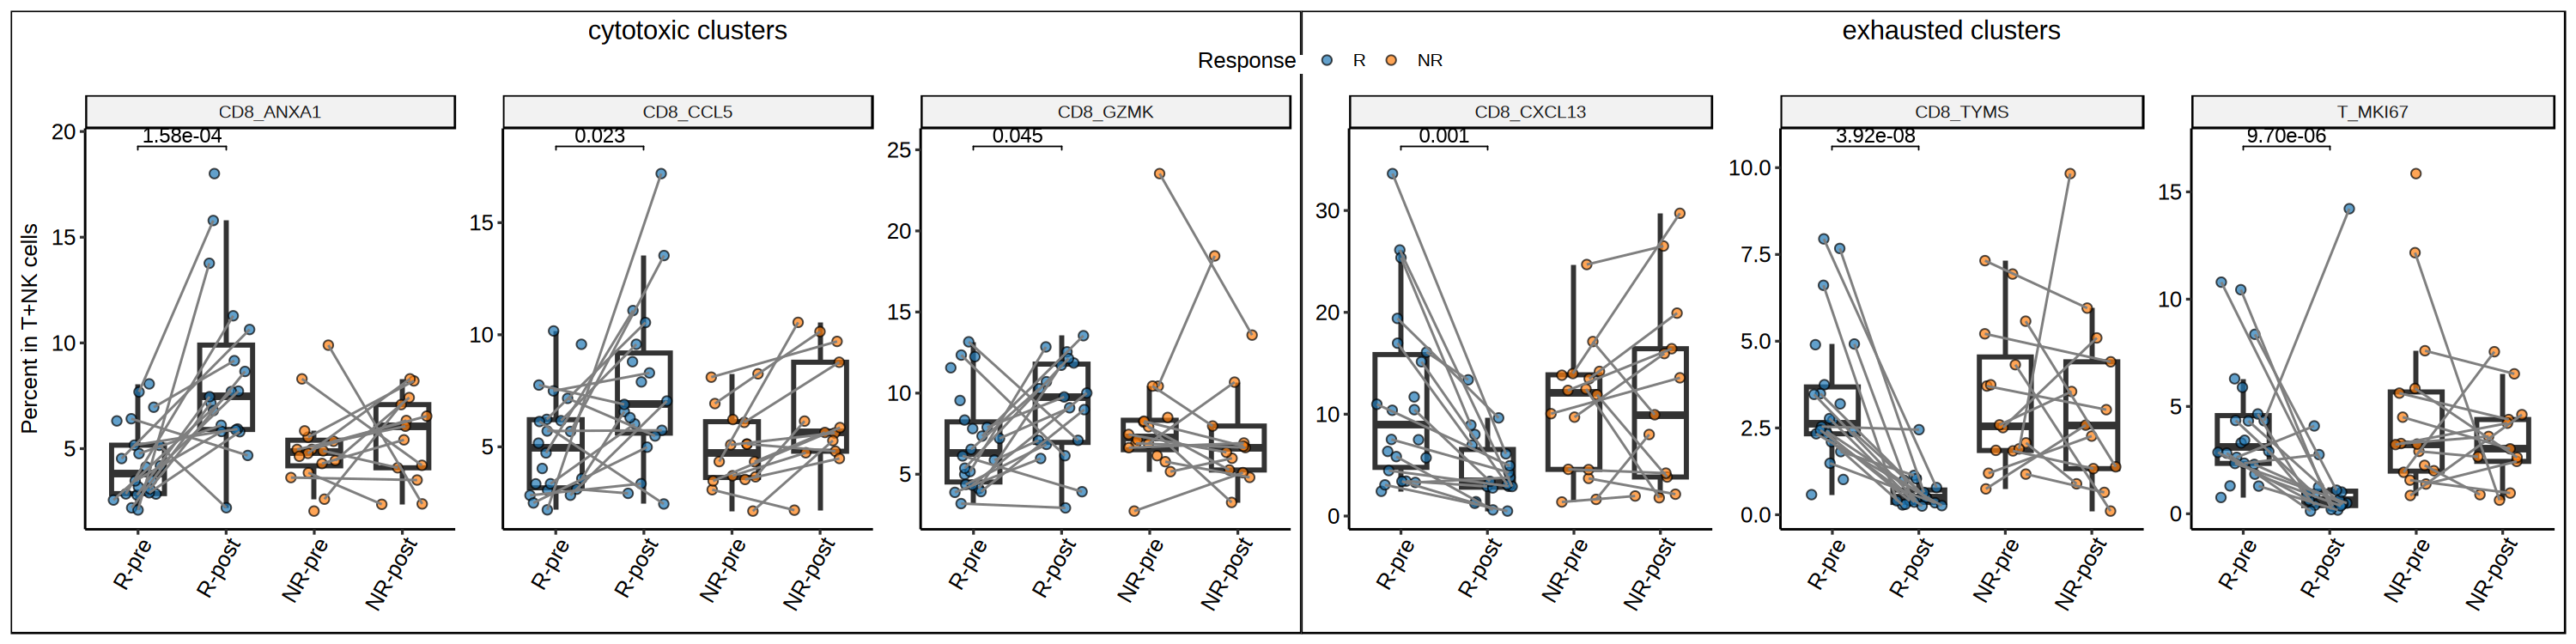

In [52]:

df <- read_tsv(str_glue('{outdir}/fig3c-t_cc.tsv'), show_col_types = FALSE)
p_ls <- lapply(names(use_ctypes), FUN = function(nm) {
    p_i <- df %>%
        filter(!is.na(.data[[gp]]), cell_type %in% use_ctypes[[nm]]) %>%
        cell_comp_boxplot(
            x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, xangle = 60, size = 2,
            xorder = comb_order, fill_order = gp_lvls[[gp]], ncol = 7
        ) +
        labs(y = 'Percent in T+NK cells', fill = 'Response', title = nm) +
        theme(
            plot.background = element_rect(color = 'black'),
            axis.title.x = element_blank(),
            plot.title = element_text(hjust = 0.5)
        )
    p_i <- configure_panel_wilcox(
        p_i,
        x = 'plot_x', y = 'pct', comparisons = comp_ls, facet_by = 'cell_type',
        use_paired = FALSE, pair_by = 'patient',
        paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
        apply_correction = TRUE, correction_method = 'BH'
    )
    print(get_panel_wilcox_stats(p_i), n = Inf)
    p_i
})
for (i in 2:length(p_ls)) {
    p_ls[[i]] <- p_ls[[i]] + theme(axis.title.y = element_blank())
}
p <- wrap_plots(p_ls, nrow = 1, widths = c(3, 3), guides = 'collect') &
    theme(legend.margin = margin(-6, 0, -1, 0))
ggsave(filename = str_glue('{outdir}/fig3c-box_cc-selected_t_subtypes.pdf'), plot = p, width = 14, height = 5)

options(repr.plot.width = 20, repr.plot.height = 5, repr.plot.res = 150)
# 在当前 notebook 中显示组合图。
p


## 3d: RVT experimental data

### Direct final plotting data

Fig. 3d is plotted directly from the final image-field resource table. This table is the final output of the original segmentation/thresholding workflow; raw mIF image inputs are not re-read here.

In [53]:
# Fig. 3d: direct input of final plotting data (one row per image field).
f_fig3d <- '../data/Figure3/core_inputs/Figure_3d_CXCL13_CD8_mIF_by_image_field.tsv'
code_order <- c('142', '140', '139', '145', '143', '144', '138', '141')

df_stat <- read_tsv(f_fig3d, show_col_types = FALSE) %>%
    mutate(
        patient_id = factor(as.character(patient_id), levels = code_order),
        RVT = as.numeric(RVT)
    )

# Optional patient-level audit table; it is not used for the image-field boxplot.
df_patient_summary <- read_tsv(
    '../data/Figure3/core_inputs/Figure_3d_CXCL13_CD8_mIF_patient_summary.tsv',
    show_col_types = FALSE
)

stopifnot(nrow(df_stat) == 135)


### plot

In [54]:
# Use one independent observation per patient: the median across image fields.
patient_group_map <- df_patient_summary %>%
    transmute(
        patient_id = as.character(patient_id),
        response_group = as.character(response_group)
    ) %>%
    distinct()

fig3d_patient_medians <- df_stat %>%
    mutate(patient_id = as.character(patient_id)) %>%
    left_join(patient_group_map, by = 'patient_id') %>%
    group_by(patient_id, response_group) %>%
    summarise(
        n_image_fields = n(),
        patient_median = median(CXCL13_CD8_in_CD8, na.rm = TRUE),
        .groups = 'drop'
    )

stopifnot(!anyNA(fig3d_patient_medians$response_group))

a <- fig3d_patient_medians %>%
    filter(response_group == 'R') %>%
    pull(patient_median)
b <- fig3d_patient_medians %>%
    filter(response_group == 'NR') %>%
    pull(patient_median)

fig3d_wilcox <- wilcox.test(
    a,
    b,
    paired = FALSE,
    alternative = 'two.sided'
)
fig3d_stats <- tibble(
    comparison = 'R vs NR',
    analysis_unit = 'patient median',
    n_R_patients = length(a),
    n_NR_patients = length(b),
    median_R = median(a),
    median_NR = median(b),
    statistic_W = unname(fig3d_wilcox$statistic),
    p_raw = fig3d_wilcox$p.value,
    p_display = p_raw
)

fig3d_patient_medians
fig3d_stats


patient_id,response_group,n_image_fields,patient_median
<chr>,<chr>,<int>,<dbl>
138,NR,12,0.41373886
139,R,7,0.14553571
140,R,11,0.08922198
141,NR,43,0.42214533
142,R,11,0.07308684
143,NR,16,0.17923875
144,NR,30,0.17100029
145,R,5,0.15545685


comparison,analysis_unit,n_R_patients,n_NR_patients,median_R,median_NR,statistic_W,p_raw,p_display
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
R vs NR,patient median,4,4,0.1173788,0.2964888,0,0.02857143,0.02857143


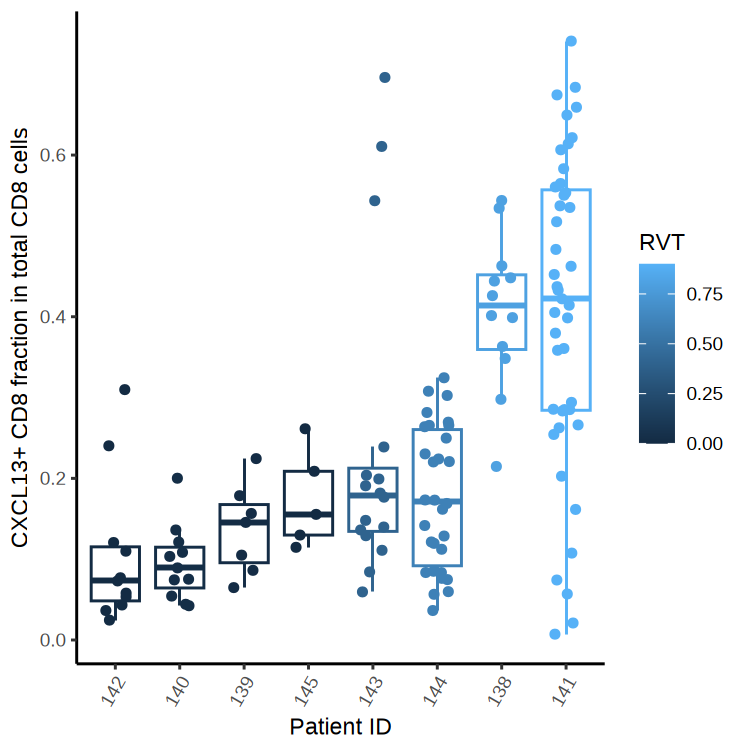

In [55]:
p <- ggplot(df_stat, aes(x=patient_id,y=CXCL13_CD8_in_CD8, color=RVT)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(position=position_jitter(0.2),aes(fill=RVT)) +
    labs(
        # title=str_glue('CXCL13_all_thresh={CXCL13_all_thresh},CD8_tot_thresh={CD8_tot_thresh}')
        x = 'Patient ID',
        y = 'CXCL13+ CD8 fraction in total CD8 cells'
    ) +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 60, vjust = 1, hjust=1))
ggsave(filename = str_glue('../output/fig3d-box-rvt.pdf'), width = 4, height = 4)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
p


## 3e: dotplot exprs of CXCR4-CXCL12

### CXCR4-CXCL12 in whole dataset

In [56]:
f_fig3e_major <- '../data/Figure3/core_inputs/Figure_3e_CXCR4_CXCL12_major_cell_dotplot.tsv'

In [57]:
dp_fig3e_major <- read_tsv(f_fig3e_major, show_col_types = FALSE) %>%
    mutate(gene = factor(gene, levels = c('CXCR4', 'CXCL12')),
           color_value = as.numeric(scale(mean_expression)), .by = gene)

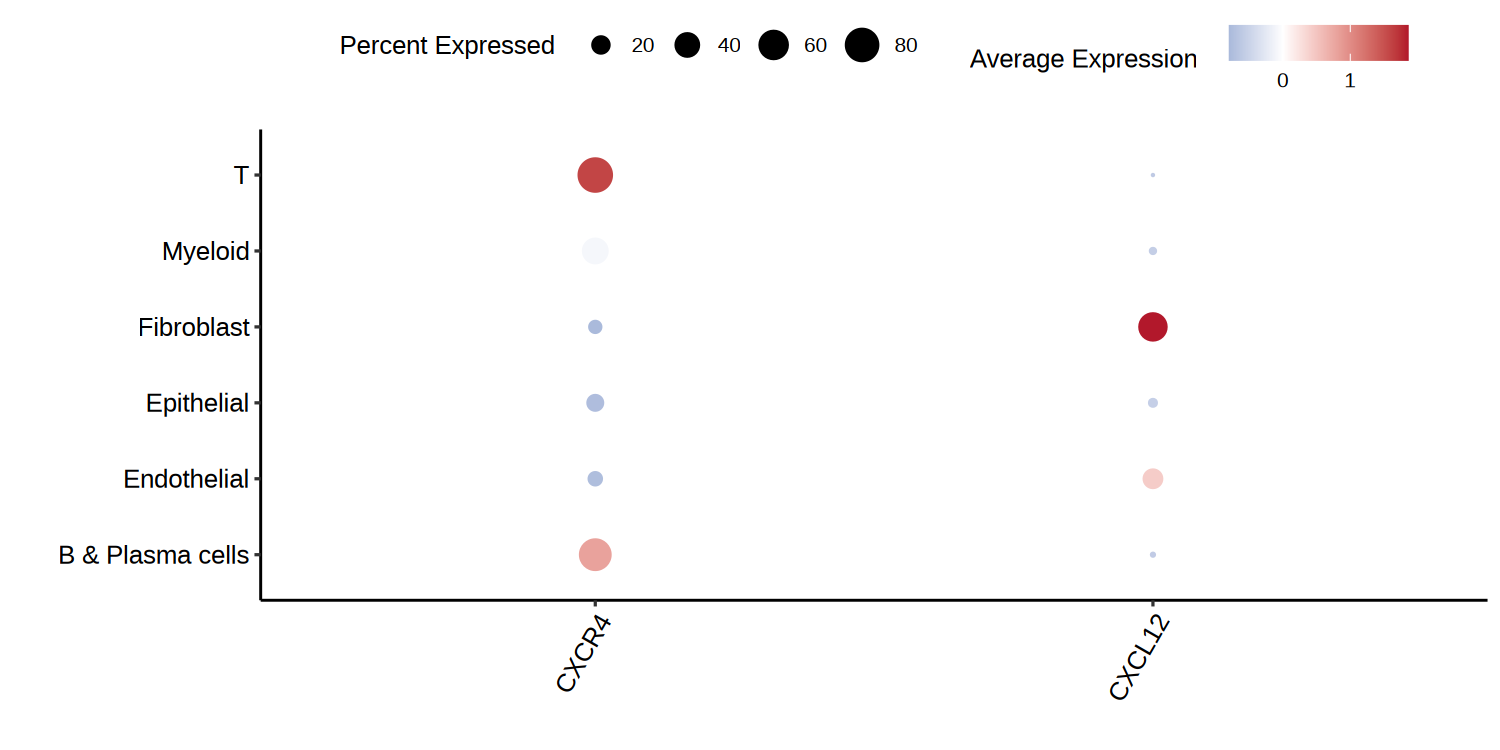

In [58]:
p <- ggplot(dp_fig3e_major, aes(x = gene, y = cell_group)) +
    geom_point(aes(size = percent_expressed, color = color_value)) +
    scale_size(range = c(0, 7), name = 'Percent Expressed') +
    scale_color_gradient2(low = '#2166AC', mid = 'white', high = '#B2182B', name = 'Average Expression') +
    labs(x = '', y = '') + theme(axis.text.x = element_text(angle = 60, hjust = 0.95, vjust = 0.95))
ggsave(filename = str_glue('{outdir}/fig3e-dotplot-CXCR4_CXCL12-exprs-major.pdf'), plot = p, width = 5, height = 5)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 150)
p


### CXCR4 in T subtypes

In [59]:
f_fig3e_t <- '../data/Figure3/core_inputs/Figure_3e_CXCR4_T_cell_dotplot.tsv'

In [60]:
dp_fig3e_t <- read_tsv(f_fig3e_t, show_col_types = FALSE) %>%
    mutate(cell_group = factor(cell_group, levels = ctype_order),
           gene = factor(gene, levels = 'CXCR4'),
           color_value = as.numeric(scale(mean_expression)), .by = gene)

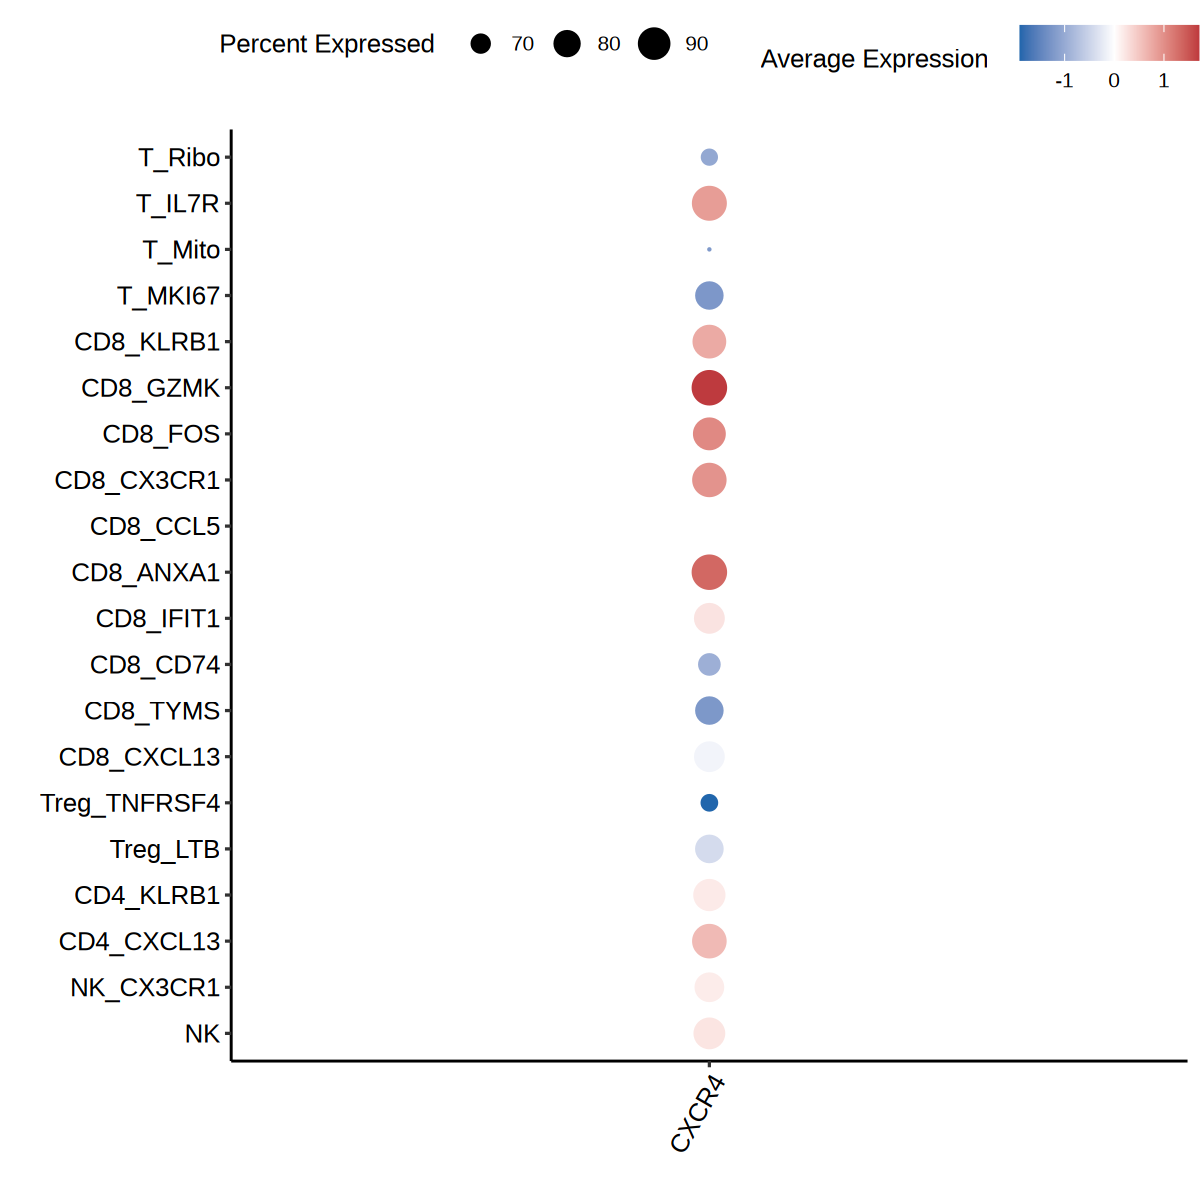

In [61]:
p <- ggplot(dp_fig3e_t, aes(x = gene, y = cell_group)) +
    geom_point(aes(size = percent_expressed, color = color_value)) +
    scale_size(range = c(0, 7), name = 'Percent Expressed') +
    scale_color_gradient2(low = '#2166AC', mid = 'white', high = '#B2182B', name = 'Average Expression') +
    labs(x = '', y = '') + theme(axis.text.x = element_text(angle = 60, hjust = 0.95, vjust = 0.95))
ggsave(filename = str_glue('{outdir}/fig3e-dotplot-CXCR4-exprs-T_clusters.pdf'), plot = p, width = 4.5, height = 5)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 150)
p


## 3f-g: pseodo-bulk expression of CXCL12/CXCR4

### CXCL12 in Fibroblast

In [62]:
f_pbulk <- '../data/Figure3/stage4/a06_de/cntbulk_major_min50/fibro/bulk_by_samp.tsv'
genes <- 'CXCL12'

In [63]:
exprs_pbulk <- read_tsv(f_pbulk, show_col_types = F) %>%
    mutate(across(where(is.numeric), ~ log1p(1e6 * .x / sum(.x)))) %>%
    filter(symbol %in% genes) %>% 
    pivot_longer(cols = -c('symbol'), names_to = 'sample', values_to = 'logcpm') %>%
    extract(col = 'sample', into = c('patient', 'sample_type'), regex = '(.+)-(.+)', remove = F) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

exprs_pbulk %>% write_tsv(str_glue('{outdir}/fig3f-exprs-CXCL12_in_fibro.tsv'))

loginfo('%g records of %g genes', nrow(exprs_pbulk), length(genes))

2026-07-17 22:48:38.123902 INFO::77 records of 1 genes


# A tibble: 4 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W    p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>    <dbl>
1 R-pre  R-post                1 FALSE     20    19      NA           3 2.03e-10
2 NR-pre NR-po…                2 FALSE     15    13      NA          21 1.78e- 4
3 R-pre  NR-pre                3 FALSE     20    15      NA         158 8.05e- 1
4 R-post NR-po…                4 FALSE     19    13      NA         189 1.11e- 2
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


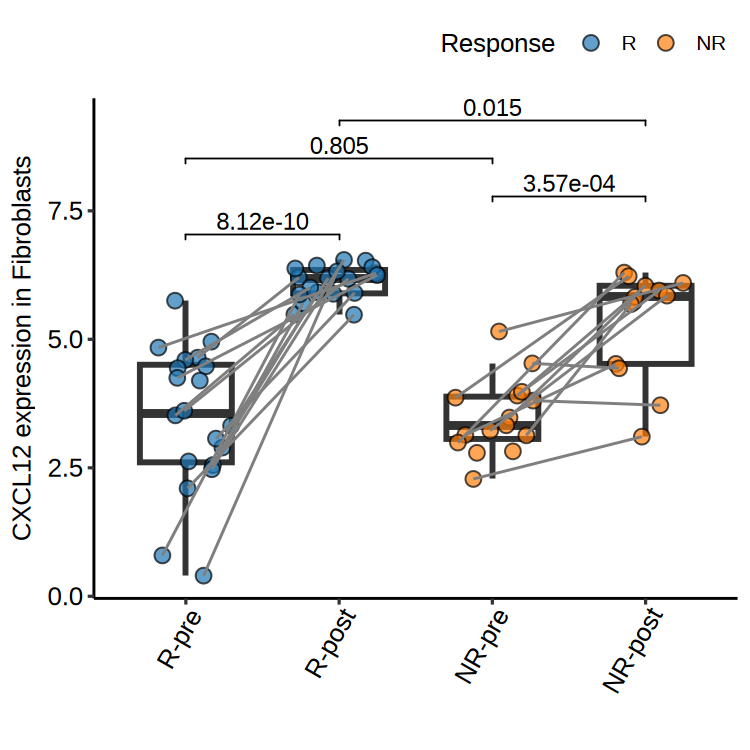

In [64]:

p <- read_tsv(str_glue('{outdir}/fig3f-exprs-CXCL12_in_fibro.tsv'), show_col_types = F) %>%
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'logcpm', pt_fill = gp, facet_by = NULL, 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60) +
    labs(fill = 'Response', y = 'CXCL12 expression in Fibroblasts') +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'logcpm',
    comparisons = gp_comp_map[[gp]],
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig3f-exprs-CXCL12_in_fibro.pdf'), width = 2.5, height = 5, plot = p)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
p


### CXCL12 in Endothelial

In [65]:
f_pbulk <- '../data/Figure3/stage4/a06_de/cntbulk_major_min50/endo/bulk_by_samp.tsv'
genes <- 'CXCL12'

In [66]:
exprs_pbulk <- read_tsv(f_pbulk, show_col_types = F) %>%
    mutate(across(where(is.numeric), ~ log1p(1e6 * .x / sum(.x)))) %>%
    filter(symbol %in% genes) %>% 
    pivot_longer(cols = -c('symbol'), names_to = 'sample', values_to = 'logcpm') %>%
    extract(col = 'sample', into = c('patient', 'sample_type'), regex = '(.+)-(.+)', remove = F) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

exprs_pbulk %>% write_tsv(str_glue('{outdir}/fig3f-exprs-CXCL12_in_endo.tsv'))

loginfo('%g records of %g genes', nrow(exprs_pbulk), length(genes))

2026-07-17 22:48:39.461231 INFO::78 records of 1 genes


# A tibble: 4 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  R-post                 1 FALSE     20    19      NA          61 1.52e-4
2 NR-pre NR-post                2 FALSE     15    13      NA          97 1   e+0
3 R-pre  NR-pre                 3 FALSE     20    15      NA          89 4.27e-2
4 R-post NR-post                4 FALSE     19    13      NA         154 2.54e-1
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


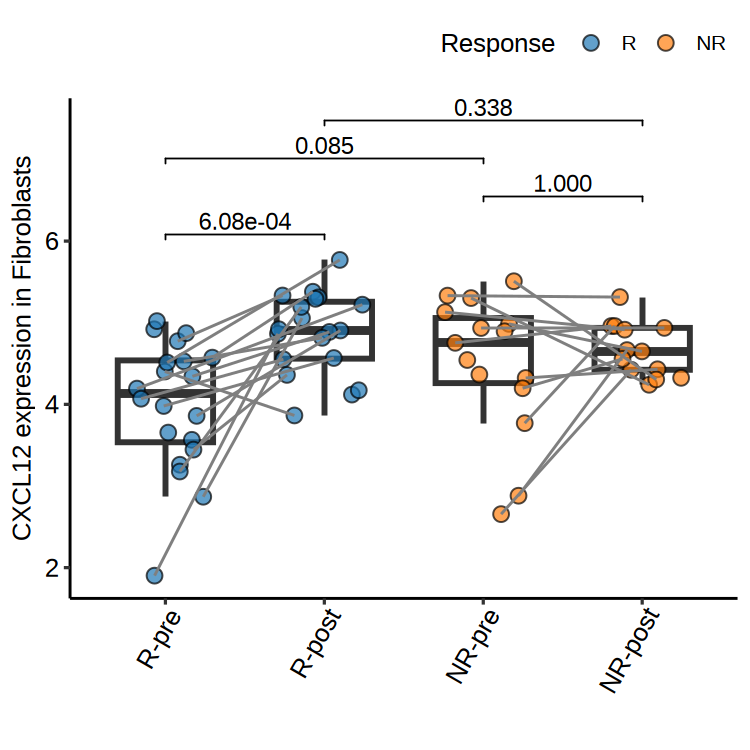

In [67]:

p <- read_tsv(str_glue('{outdir}/fig3f-exprs-CXCL12_in_endo.tsv'), show_col_types = F) %>%
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'logcpm', pt_fill = gp, facet_by = NULL, 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60) +
    labs(fill = 'Response', y = 'CXCL12 expression in Fibroblasts') +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'logcpm',
    comparisons = gp_comp_map[[gp]],
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig3f-exprs-CXCL12_in_fibro.pdf'), width = 2.5, height = 5, plot = p)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
p


### CXCR4 in cytotoxic CD8 T

In [68]:
f_pbulk <- '../data/Figure3/stage4/miscellaneous/exprs_box/chemokine_receptor_in_t_state-exprs-pbulk.tsv'
used_gene <- 'CXCR4'

In [69]:
exprs_pbulk <- read_tsv(f_pbulk, show_col_types = F) %>% 
    filter(gene == used_gene, cellgp == 'cytotoxic CD8') %>% 
    select(patient, sample_type, logcpm) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
loginfo('%g records', nrow(exprs_pbulk))

exprs_pbulk %>% write_tsv(str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_cyto_T.tsv'))

2026-07-17 22:48:40.722291 INFO::81 records


# A tibble: 4 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  R-post                 1 FALSE     22    19      NA         103 0.00493
2 NR-pre NR-post                2 FALSE     16    13      NA          90 0.559  
3 R-pre  NR-pre                 3 FALSE     22    16      NA         153 0.510  
4 R-post NR-post                4 FALSE     19    13      NA         146 0.404  
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


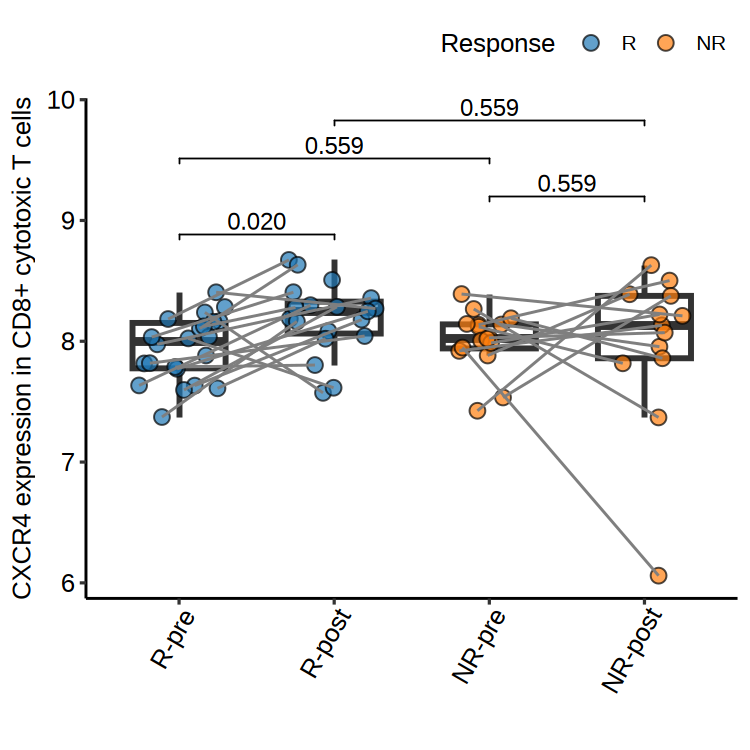

In [70]:

p <- read_tsv(str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_cyto_T.tsv'), show_col_types = F) %>%
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'logcpm', pt_fill = gp, facet_by = NULL, 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60) +
    labs(fill = 'Response', y = 'CXCR4 expression in CD8+ cytotoxic T cells')  +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'logcpm',
    comparisons = gp_comp_map[[gp]],
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_cyto_T.pdf'), width = 2.5, height = 5, plot = p)
# 在当前 notebook 中显示最后生成的图。
p


### CXCR4 in exhausted CD8 T

In [71]:
f_pbulk <- '../data/Figure3/stage4/miscellaneous/exprs_box/chemokine_receptor_in_t_state-exprs-pbulk.tsv'
used_gene <- 'CXCR4'

In [72]:
exprs_pbulk <- read_tsv(f_pbulk, show_col_types = F) %>% 
    filter(gene == used_gene, cellgp == 'exhausted CD8') %>% 
    select(patient, sample_type, logcpm) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
loginfo('%g records', nrow(exprs_pbulk))

exprs_pbulk %>% write_tsv(str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_exhau_T.tsv'))

2026-07-17 22:48:43.978526 INFO::73 records


# A tibble: 4 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  R-post                 1 FALSE     22    12      NA           0 3.65e-9
2 NR-pre NR-post                2 FALSE     16    12      NA          55 5.93e-2
3 R-pre  NR-pre                 3 FALSE     22    16      NA         158 6.09e-1
4 R-post NR-post                4 FALSE     12    12      NA         118 6.81e-3
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


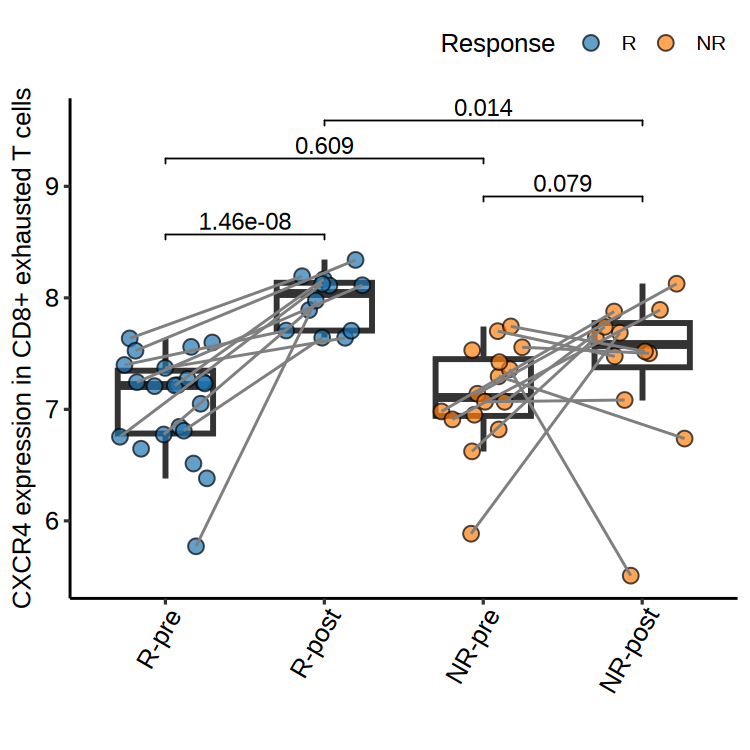

In [73]:

p <- read_tsv(str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_exhau_T.tsv'), show_col_types = F) %>%
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'logcpm', pt_fill = gp, facet_by = NULL, 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60) +
    labs(fill = 'Response', y = 'CXCR4 expression in CD8+ exhausted T cells')  +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'logcpm',
    comparisons = gp_comp_map[[gp]],
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig3f-exprs-CXCR4_in_cd8_exhau_T.pdf'), width = 2.5, height = 5, plot = p)
# 在当前 notebook 中显示最后生成的图。
p


## Export the final core resource data